# Fuzzy Regression Discontinuity — Government Transfers & Political Support

Working through this step by step.

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf


In [154]:
df = pd.read_csv("../data/raw/gov_transfers.csv")

print(df.shape)
df.head()


(1948, 5)


,Income_Centered,Education,Age,Participation,Support
0,0.006571,3.5,23.666666,0,1.0
1,0.011075,1.5,42.000000,0,1.0
2,0.002424,4.0,43.000000,0,1.0
3,0.007650,6.0,21.000000,0,0.5
4,0.010001,2.0,33.000000,0,1.0


- Income_Centered — household income minus the eligibility threshold. Negative = below the cutoff = income-eligible for the transfer. This is our forcing variable.
- Education, Age — household averages, useful later for a balance check (same role state_population played last time).
- Participation — did the household actually enroll in the transfer program (0/1). This is the treatment, and notice it's separate from eligibility — that's the fuzzy part.
- Support — measure of political support for the government (looks continuous here, e.g. 1.0, 0.5 — not a strict 0/1, wor

In [155]:
columns = {col: col.lower() for col in df.columns}
df = df.rename(columns=columns)

## validate

In [156]:
df.isnull().sum()

income_centered     0
education          51
age                 0
participation       0
support             0
dtype: int64

In [157]:
df = df[~df['education'].isnull()]

## Visualize

<Axes: >

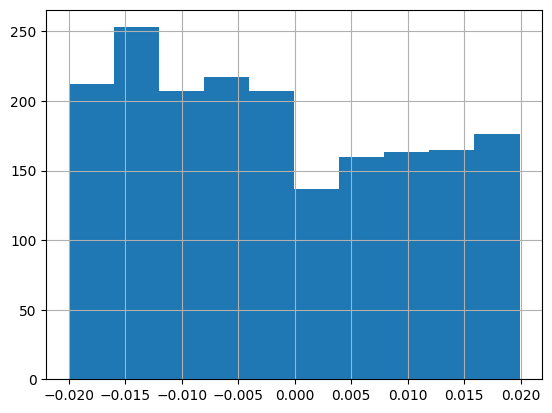

In [158]:
df["income_centered"].hist()

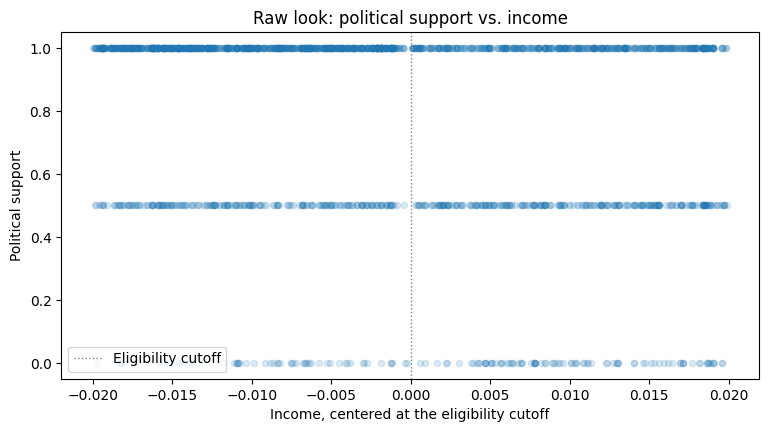

In [159]:
fig, ax = plt.subplots(figsize=(9, 4.5))
df.plot.scatter(x="income_centered", y="support", ax=ax, alpha=0.15)
ax.axvline(0, color="grey", linestyle=":", linewidth=1, label="Eligibility cutoff")
ax.set_xlabel("Income, centered at the eligibility cutoff")
ax.set_ylabel("Political support")
ax.set_title("Raw look: political support vs. income")
ax.legend()


In [160]:
from scipy.stats import binomtest

# Manipulation check runs on the density file (wider, unrestricted range),
# not gov_transfers.csv, which is already pre-limited to households near the cutoff.
density_df = pd.read_csv("../data/raw/gov_transfers_density.csv")
density_df.columns = [c.lower() for c in density_df.columns]

window = 0.01  # income points on each side of the cutoff

just_below = density_df[(density_df["income_centered"] >= -window) & (density_df["income_centered"] < 0)]
just_above = density_df[(density_df["income_centered"] >= 0) & (density_df["income_centered"] < window)]

n_below = len(just_below)
n_above = len(just_above)
n_total = n_below + n_above

result = binomtest(n_above, n_total, p=0.5)

print(f"Households in [-{window}, 0)  : {n_below}")
print(f"Households in [0, {window})   : {n_above}")
print(f"Total in window               : {n_total}")
print(f"p-value                       : {result.pvalue:.3f}")


Households in [-0.01, 0)  : 4793
Households in [0, 0.01)   : 5333
Total in window               : 10126
p-value                       : 0.000


In [161]:
result

BinomTestResult(k=5333, n=10126, alternative='two-sided', statistic=0.5266640331819079, pvalue=8.43428874697285e-08)

In [162]:
df

,income_centered,education,age,participation,support
0,0.006571,3.5,23.666666,0,1.0
1,0.011075,1.5,42.000000,0,1.0
2,0.002424,4.0,43.000000,0,1.0
3,0.007650,6.0,21.000000,0,0.5
4,0.010001,2.0,33.000000,0,1.0
...,...,...,...,...,...
1943,-0.013489,2.0,27.333334,1,1.0
1944,-0.012106,4.5,37.000000,1,1.0
1945,-0.010159,5.0,25.857143,1,1.0
1946,-0.008668,3.0,26.000000,1,1.0


In [163]:
df['income_centered'].max(), df['income_centered'].min()

(np.float64(0.019892002), np.float64(-0.019990994))

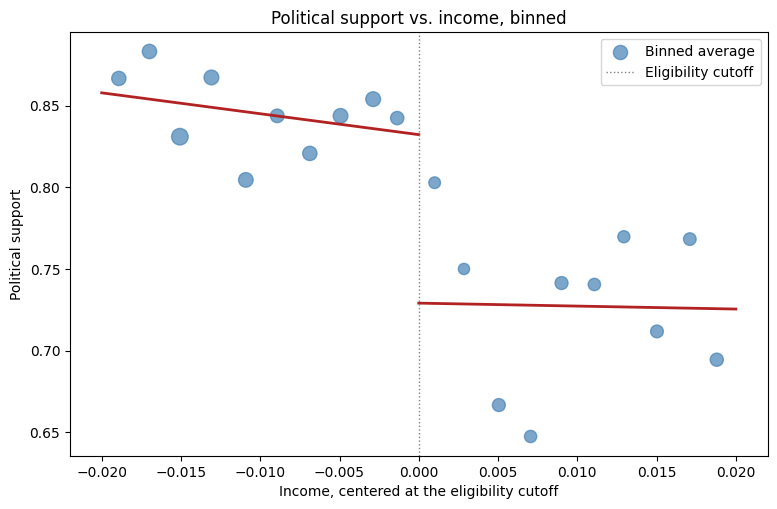

In [164]:
# support only takes 3 discrete values (0, 0.5, 1.0), so a raw scatter is just
# three horizontal stripes and hides the pattern -- bin by income instead.
BIN_WIDTH = 0.002
bin_min, bin_max = df["income_centered"].min(), df["income_centered"].max()
bin_edges = np.arange(bin_min, bin_max + BIN_WIDTH, BIN_WIDTH)
df = df.assign(income_bin=pd.cut(df["income_centered"], bin_edges, include_lowest=True))

binned = df.groupby("income_bin", observed=True).agg(
    income_mid=("income_centered", "mean"),
    support_mean=("support", "mean"),
    n=("support", "size"),
).dropna()

left = df[df["income_centered"] < 0]
right = df[df["income_centered"] >= 0]

left_coefs = np.polyfit(left["income_centered"], left["support"], deg=1)
right_coefs = np.polyfit(right["income_centered"], right["support"], deg=1)

grid_left = np.linspace(-0.02, 0, 100)
grid_right = np.linspace(0, 0.02, 100)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(binned["income_mid"], binned["support_mean"], s=binned["n"], color="steelblue", alpha=0.7, label="Binned average")
ax.plot(grid_left, np.polyval(left_coefs, grid_left), color="firebrick", linewidth=2)
ax.plot(grid_right, np.polyval(right_coefs, grid_right), color="firebrick", linewidth=2)
ax.axvline(0, color="grey", linestyle=":", linewidth=1, label="Eligibility cutoff")
ax.set_xlabel("Income, centered at the eligibility cutoff")
ax.set_ylabel("Political support")
ax.set_title("Political support vs. income, binned")
ax.legend()


In [165]:
df['income_centered'] * df['participation']

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
1943   -0.013489
1944   -0.012106
1945   -0.010159
1946   -0.008668
1947   -0.003640
Length: 1897, dtype: float64

In [166]:
df.groupby('support')['participation'].mean()

support
0.0    0.398693
0.5    0.461702
1.0    0.642072
Name: participation, dtype: float64

In [167]:

formula = "support ~ participation + age + education + income_centered"

model = smf.ols(formula=formula, data=df).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                support   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     17.34
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           5.60e-14
Time:                        10:25:41   Log-Likelihood:                -480.76
No. Observations:                1897   AIC:                             971.5
Df Residuals:                    1892   BIC:                             999.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.7738      0.030     25.667      0.000       0.715       0.833
participation       0.1010      0.030      3.404      0.001       0.043       0.159
age                -0.0007      0.001     -1.420      0.156      -0.002       0.000
education          -0.0041      0.005     -0.864      0.388      -0.013       0.005
income_centered    -0.6864      1.261     -0.544      0.586      -3.160       1.788
==============================================================================
Omnibus:                      324.424   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              508.096
Skew:                          -1.240   Prob(JB):                    4.66e-111
Kurtosis:                       3.524   Cond. No.                     5.66e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.66e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Covariate balance check

`age` and `education` are household characteristics that existed before the transfer program and can't have been caused by it. If close-to-the-cutoff households are comparable — the core RD assumption — neither should show a jump at the cutoff. Same regression shape as the main estimate, just with a predetermined covariate as the outcome instead of `support`. If `threshold` came out significant here, that would be a red flag that eligible and ineligible households differ systematically even before the program, not because of it.

In [168]:
age_balance = smf.ols("age ~ participation + income_centered", data=df).fit()
age_balance.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    age   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     27.88
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.17e-12
Time:                        10:25:42   Log-Likelihood:                -7668.5
No. Observations:                1897   AIC:                         1.534e+04
Df Residuals:                    1894   BIC:                         1.536e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          29.6612      0.753     39.402      0.000      28.185      31.138
participation      -1.1814      1.310     -0.902      0.367      -3.751       1.388
income_centered   158.0478     55.622      2.841      0.005      48.961     267.135
==============================================================================
Omnibus:                      217.921   Durbin-Watson:                   2.034
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              295.660
Skew:                           0.948   Prob(JB):                     6.28e-65
Kurtosis:                       3.380   Cond. No.                         208.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [169]:
education_balance = smf.ols("education ~ participation + income_centered", data=df).fit()
education_balance.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              education   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.3050
Date:                Mon, 03 Aug 2026   Prob (F-statistic):              0.737
Time:                        10:25:42   Log-Likelihood:                -3498.6
No. Observations:                1897   AIC:                             7003.
Df Residuals:                    1894   BIC:                             7020.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.0197      0.084     48.102      0.000       3.856       4.184
participation       0.0940      0.145      0.646      0.518      -0.191       0.379
income_centered     2.1525      6.174      0.349      0.727      -9.957      14.262
==============================================================================
Omnibus:                      223.491   Durbin-Watson:                   2.035
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               88.431
Skew:                          -0.320   Prob(JB):                     6.27e-20
Kurtosis:                       2.157   Cond. No.                         208.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""